In [1]:
import pandas as pd
import pickle
import sys
from pathlib import Path

from sklearn.model_selection import train_test_split

sys.path.append(str(Path.cwd().parent))
from utils.helpers import Helpers

In [2]:
helper = Helpers()
properties = helper.load_properties()

try:
    cleaned_file_name = properties['LOCAL']['cleaned_file_name']
    transformer_file_name = properties['LOCAL']['transformer_file_name']
    RANDOM_STATE = properties['models']['random_state']
except KeyError as ke:
    raise KeyError(f"Missing key in properties file: {str(ke)}") from ke

In [3]:
# Apply global settings
helper.set_global_settings()

In [4]:
file_path = helper.root_dir / "datasets" / cleaned_file_name

df = pd.read_csv(file_path)
df.head()

,person_age,person_gender,person_education,person_income,person_employment_experience,person_home_ownership,loan_amount,loan_intent,loan_interest_rate,credit_history_length,credit_score,previous_loan_defaults,loan_status
0,22,female,master,71948.00,0,rent,22500.00,personal,16.02,3.00,561,no,1
1,21,female,high_school,12282.00,0,own,1000.00,education,11.14,2.00,504,yes,0
2,25,female,high_school,12438.00,3,mortgage,5500.00,medical,12.87,3.00,635,no,1
3,23,female,bachelor,79753.00,0,rent,22500.00,medical,15.23,2.00,675,no,1
4,24,male,master,66135.00,1,rent,22500.00,medical,14.27,4.00,586,no,1


In [5]:
df.shape

(42531, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42531 entries, 0 to 42530
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   person_age                    42531 non-null  int64  
 1   person_gender                 42531 non-null  object 
 2   person_education              42531 non-null  object 
 3   person_income                 42531 non-null  float64
 4   person_employment_experience  42531 non-null  int64  
 5   person_home_ownership         42531 non-null  object 
 6   loan_amount                   42531 non-null  float64
 7   loan_intent                   42531 non-null  object 
 8   loan_interest_rate            42531 non-null  float64
 9   credit_history_length         42531 non-null  float64
 10  credit_score                  42531 non-null  int64  
 11  previous_loan_defaults        42531 non-null  object 
 12  loan_status                   42531 non-null  int64  
dtypes

In [7]:
cat_variables = [
    'person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults'
    ]

num_variables = [
                    'person_age', 'person_income', 'person_employment_experience', 'loan_amount', 'loan_interest_rate', 
                    'credit_history_length', 'credit_score'
                ]

target_variable = 'loan_status'

In [8]:
for col in cat_variables:
    print(df[col].value_counts(normalize=True))
    print("-" * 30, "\n")

person_gender
male     0.55
female   0.45
Name: proportion, dtype: float64
------------------------------ 

person_education
bachelor      0.30
associate     0.26
high_school   0.26
master        0.16
doctorate     0.01
Name: proportion, dtype: float64
------------------------------ 

person_home_ownership
rent       0.53
mortgage   0.41
own        0.07
other      0.00
Name: proportion, dtype: float64
------------------------------ 

loan_intent
education            0.21
medical              0.19
venture              0.17
personal             0.17
debt_consolidation   0.16
home_improvement     0.10
Name: proportion, dtype: float64
------------------------------ 

previous_loan_defaults
yes   0.51
no    0.49
Name: proportion, dtype: float64
------------------------------ 



In [9]:
person_gender_mapping = {
    'male': 0, 
    'female': 1
    }

person_education_mapping = {
    'high_school': 0, 
    'associate': 1, 
    'bachelor': 2, 
    'master': 3, 
    'doctorate': 4
    }

person_home_ownership_mapping = {
    'other': 0, 
    'rent': 1, 
    'mortgage': 2, 
    'own': 3
    }

loan_intent_mapping = {
    'venture': 0, 
    'medical': 1, 
    'personal': 2, 
    'education': 3, 
    'home_improvement': 4, 
    'debt_consolidation': 5
    }

previous_loan_defaults_mapping = {
    'no': 0, 
    'yes': 1
    }


for col in cat_variables:
    df[col] = df[col].map(globals()[f"{col}_mapping"])

# Rename person_gender to is_female for clarity
df.rename(columns={'person_gender': 'is_female'}, inplace=True)
cat_variables[0] = 'is_female'

df[cat_variables].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42531 entries, 0 to 42530
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   is_female               42531 non-null  int64
 1   person_education        42531 non-null  int64
 2   person_home_ownership   42531 non-null  int64
 3   loan_intent             42531 non-null  int64
 4   previous_loan_defaults  42531 non-null  int64
dtypes: int64(5)
memory usage: 1.6 MB


In [10]:
target_variable = 'loan_status'

X = df.drop(columns=[target_variable])
y = df[target_variable]

# Split the data into training (70%), validation (20%), and test (10%) sets
X_train, X_rem, y_train, y_rem = train_test_split(
    X, 
    y, 
    train_size=0.7, 
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_rem, 
    y_rem, 
    train_size=2/3, 
    stratify=y_rem,
    random_state=RANDOM_STATE
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 29771 samples
Validation set size: 8506 samples
Test set size: 4254 samples


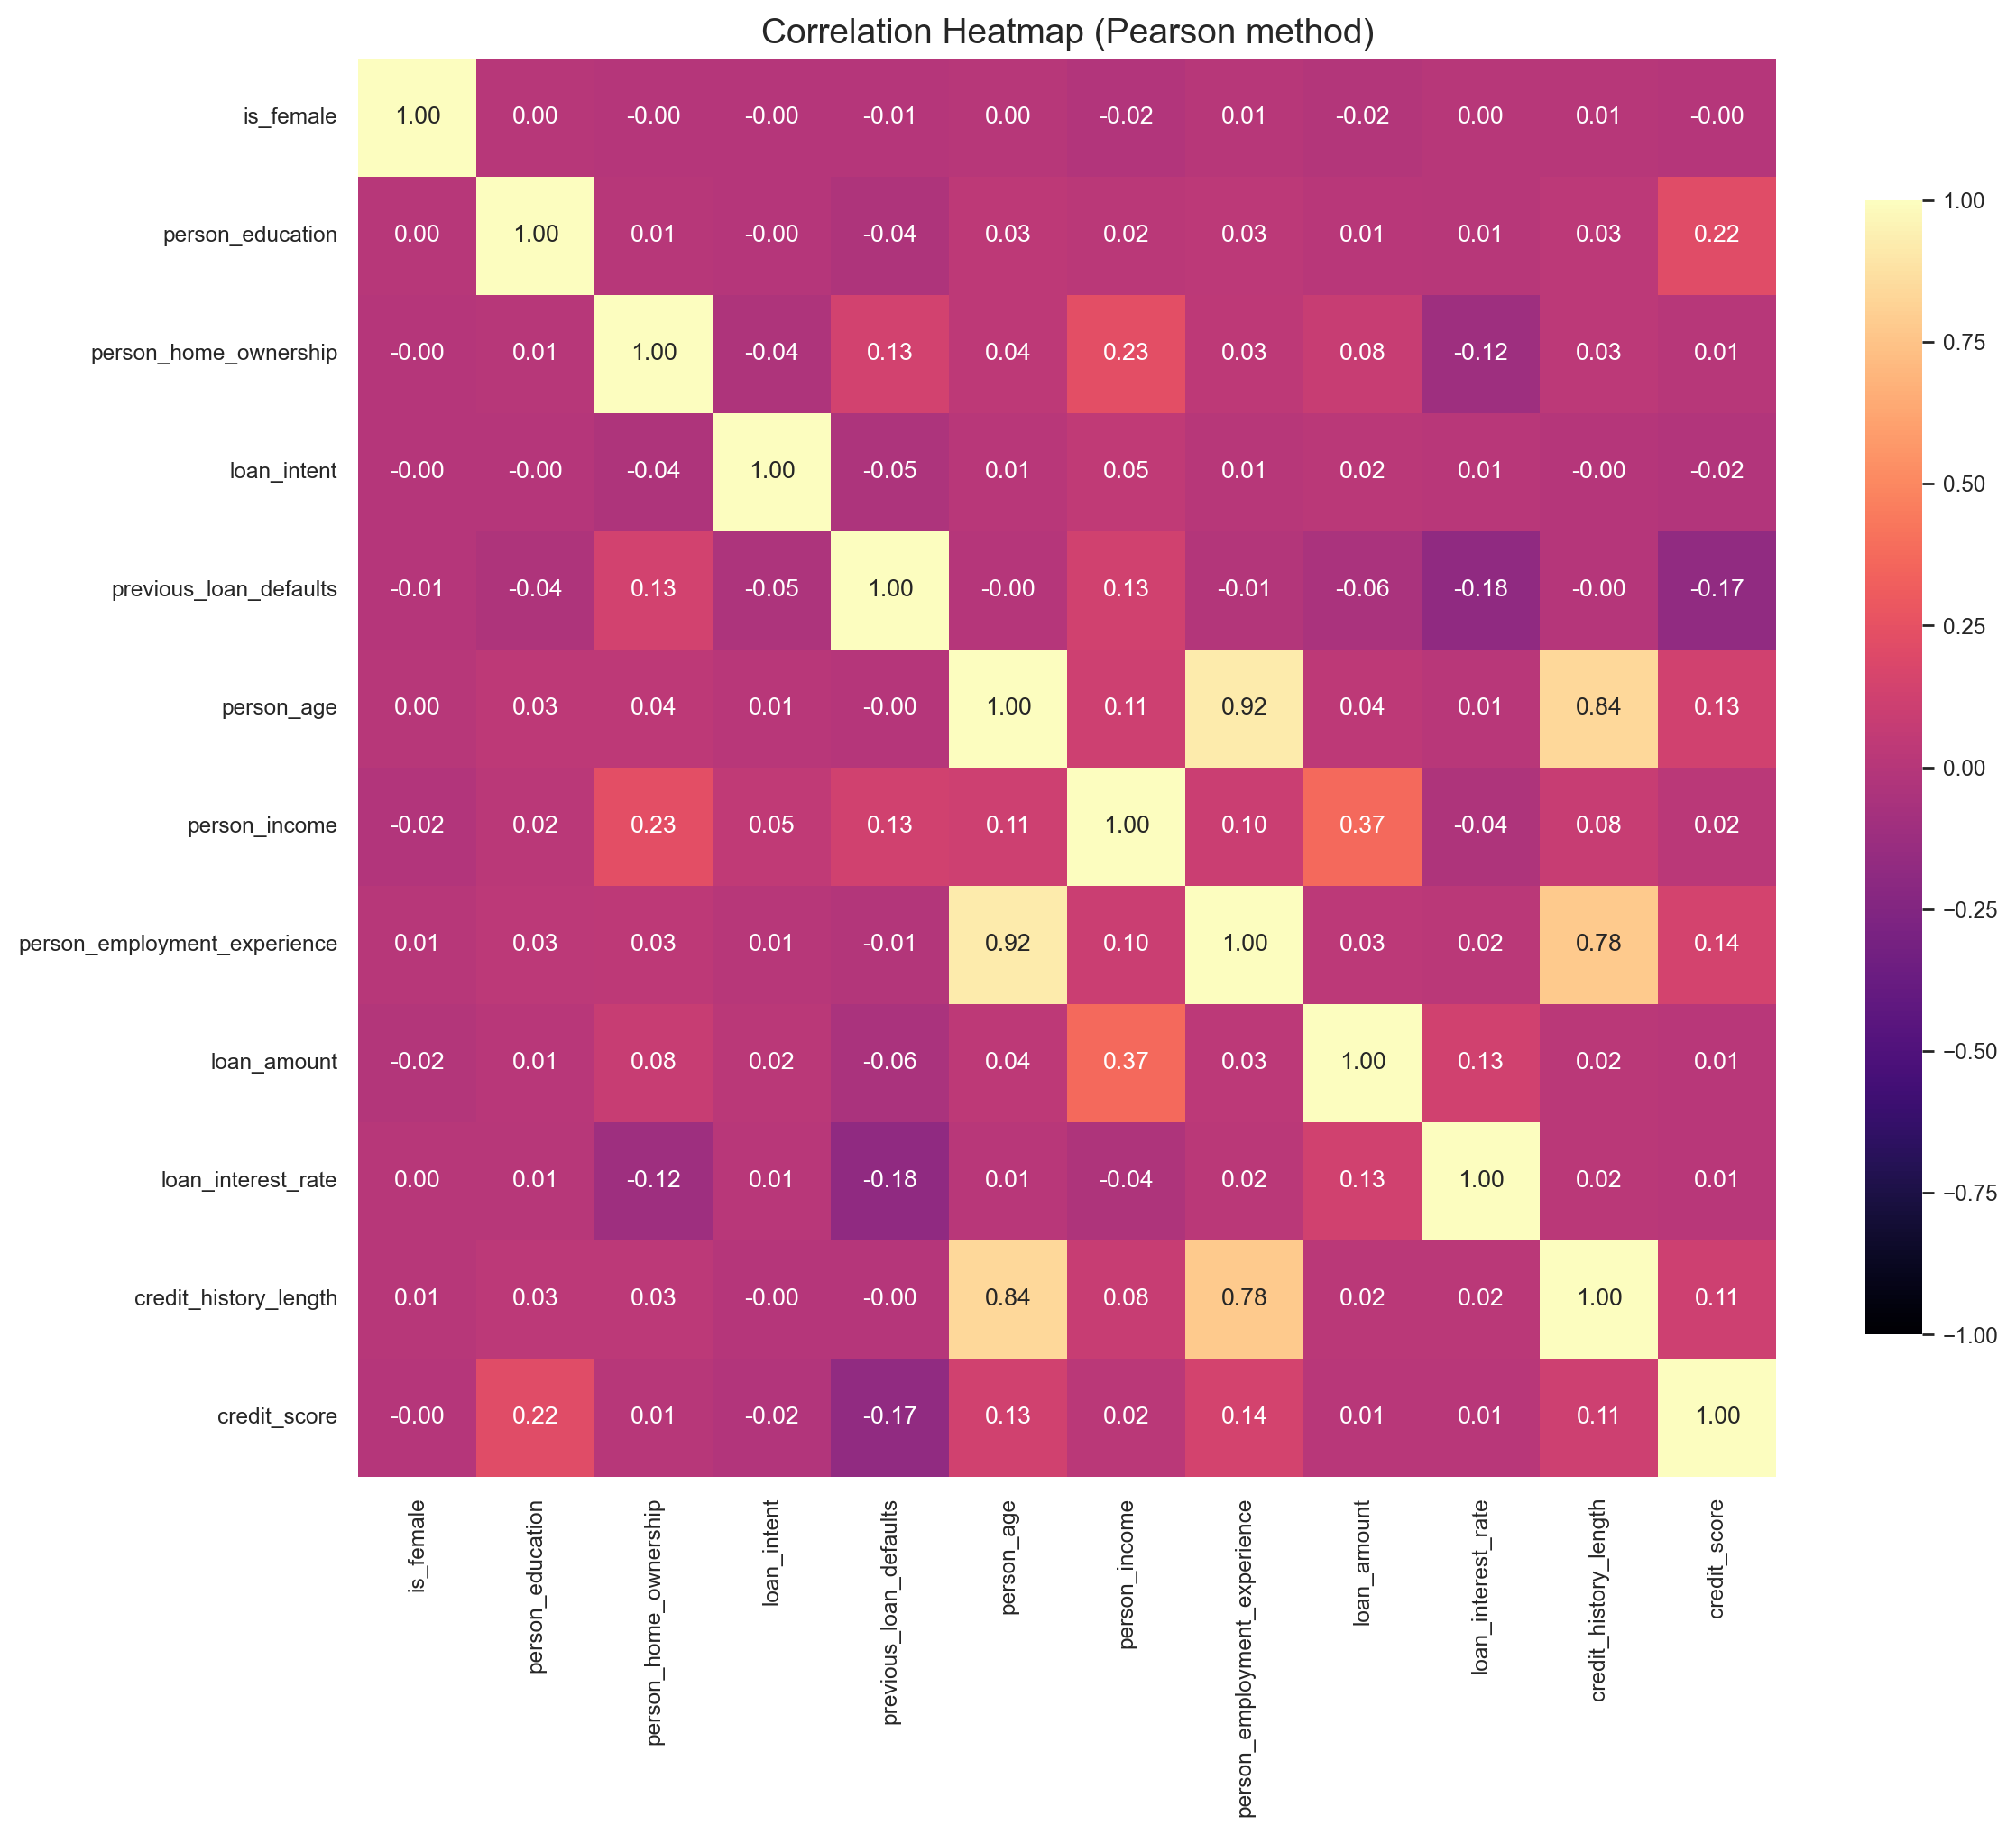

In [11]:
helper.create_correlation_heatmap(X_train[cat_variables + num_variables])

In [12]:
X_train.drop(['credit_history_length', 'person_employment_experience'], axis=1, inplace=True)

# Remove in validation and test set too
X_val.drop(['credit_history_length', 'person_employment_experience'], axis=1, inplace=True)
X_test.drop(['credit_history_length', 'person_employment_experience'], axis=1, inplace=True)

num_variables.remove('credit_history_length')
num_variables.remove('person_employment_experience')

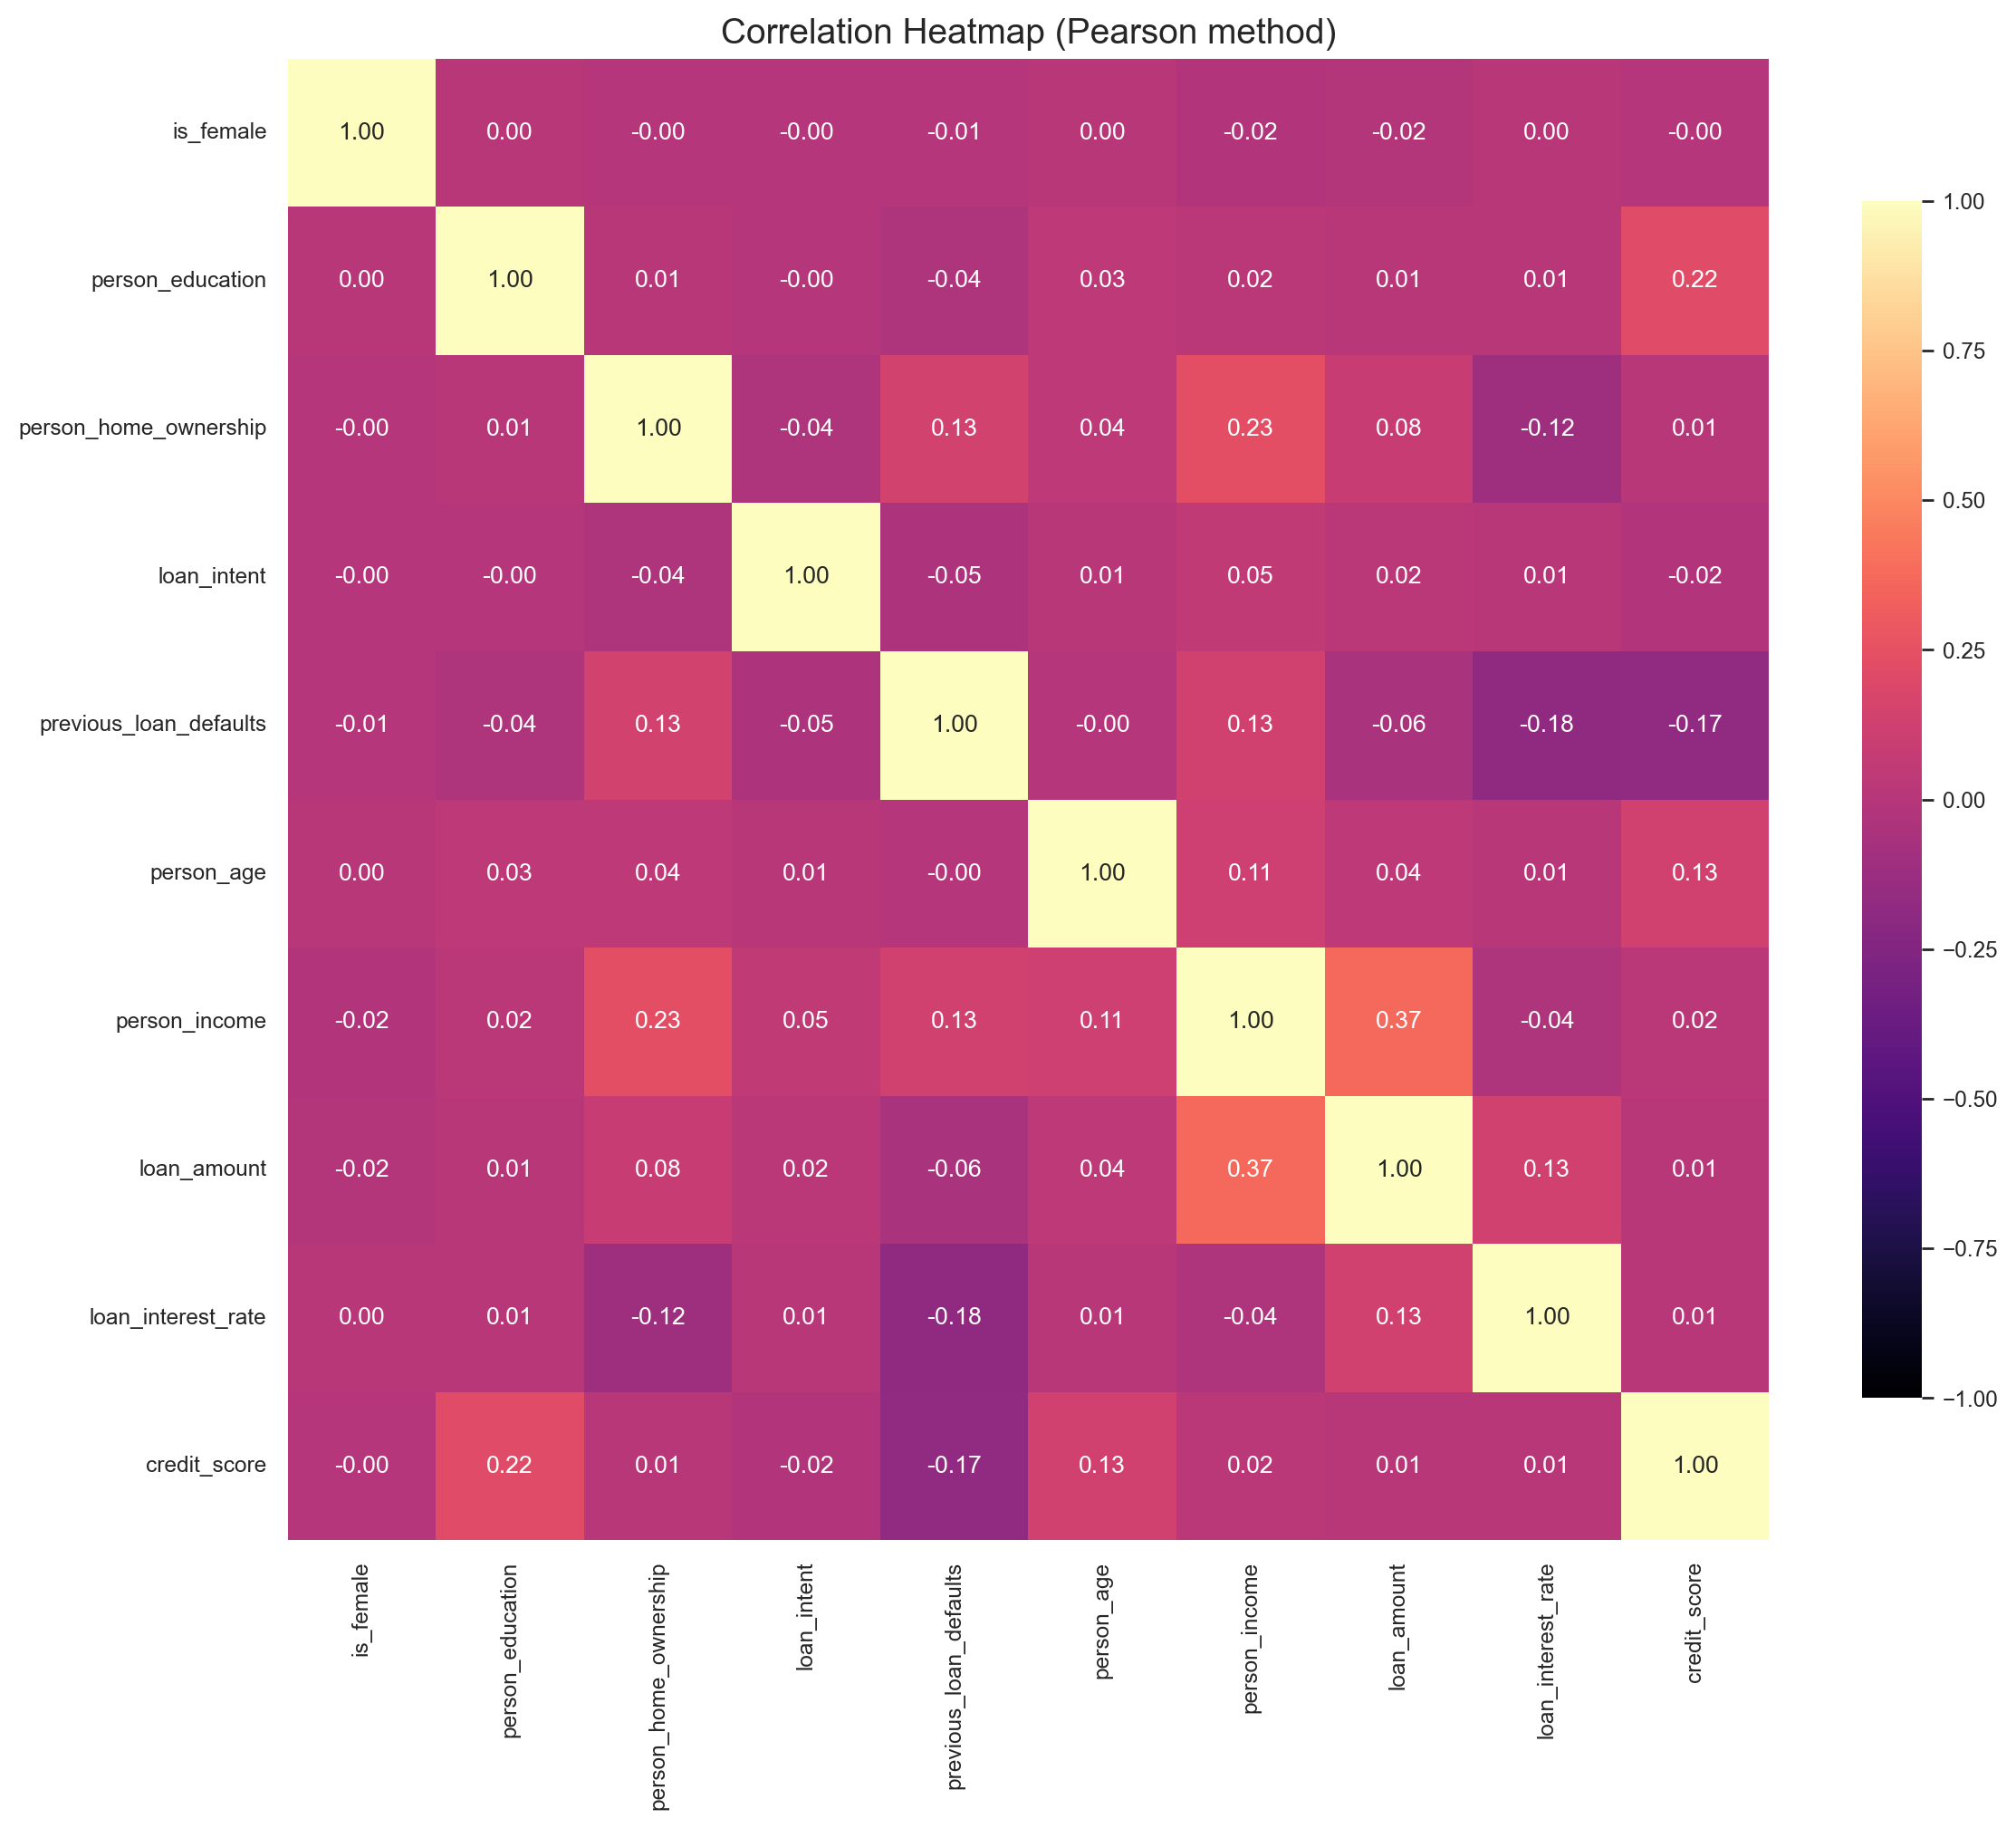

In [13]:
helper.create_correlation_heatmap(X_train[cat_variables + num_variables])

In [14]:
X_train[num_variables].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
person_age,29771.00,26.89,4.34,20.00,23.00,26.00,29.00,38.00
person_income,29771.00,74000.55,36174.59,8000.00,46836.50,66723.00,93418.00,162994.25
loan_amount,29771.00,9166.42,5581.89,500.00,5000.00,8000.00,12000.00,22500.00
loan_interest_rate,29771.00,10.99,2.96,5.42,8.59,11.01,12.99,19.62
credit_score,29771.00,631.86,49.24,498.00,601.00,639.00,669.00,762.00


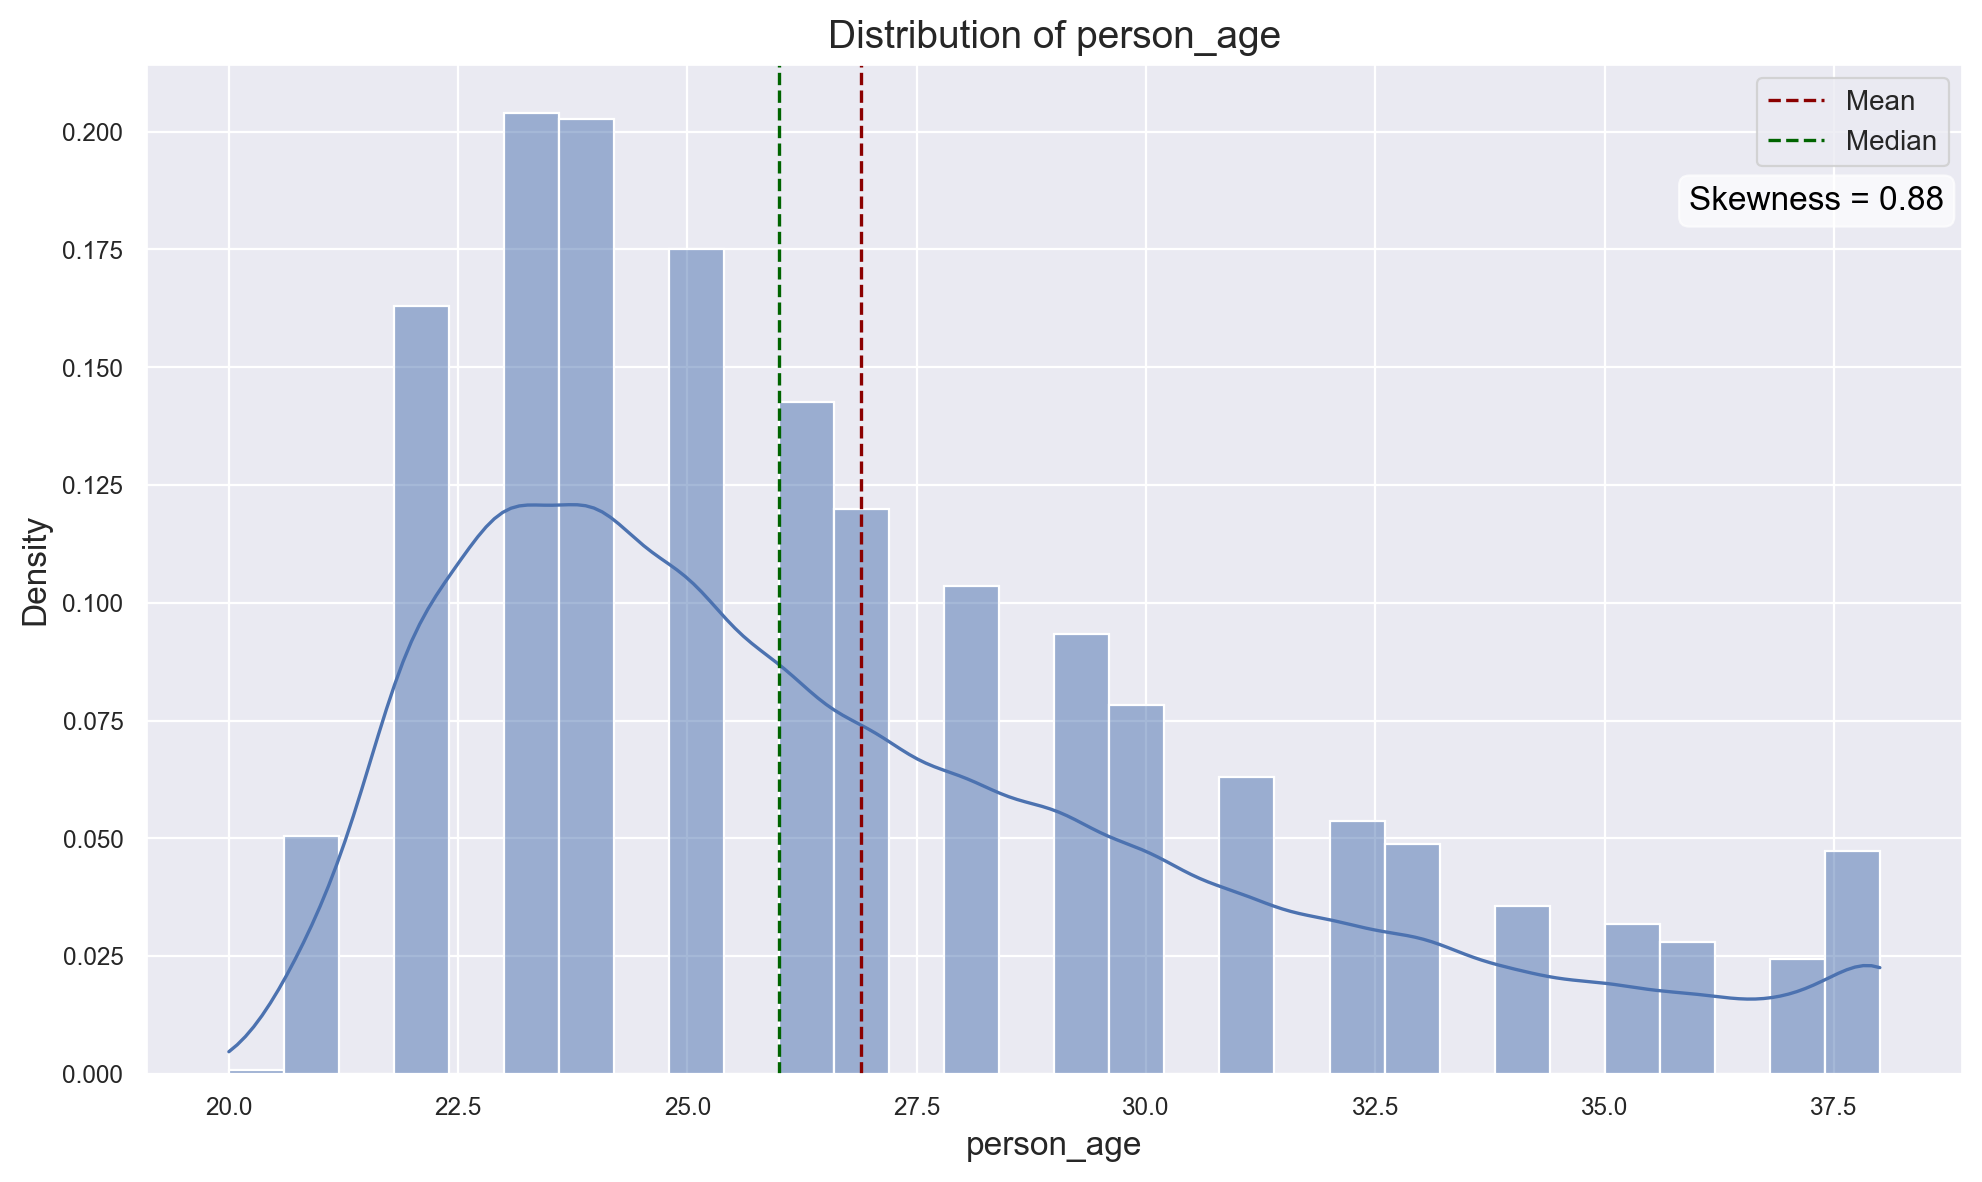

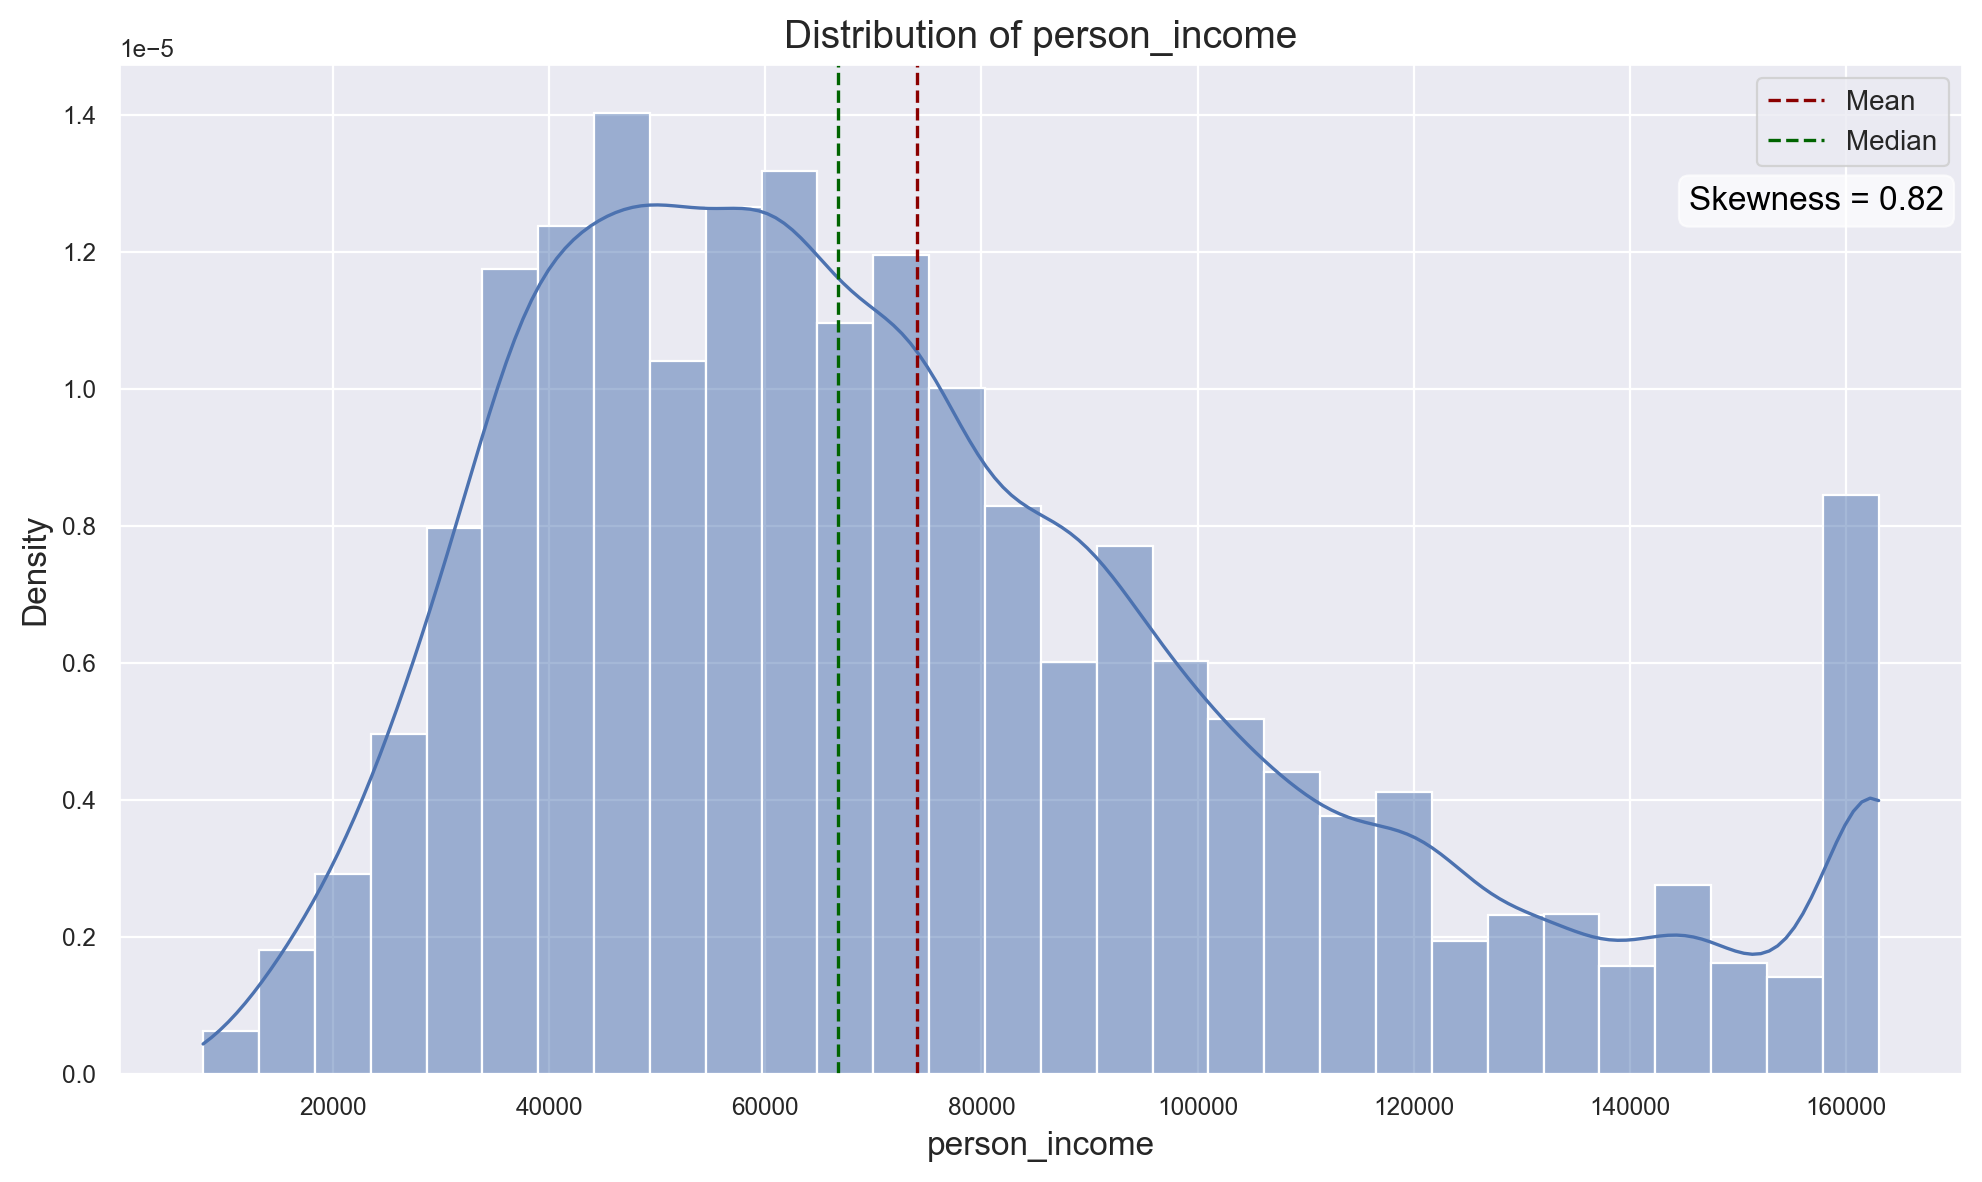

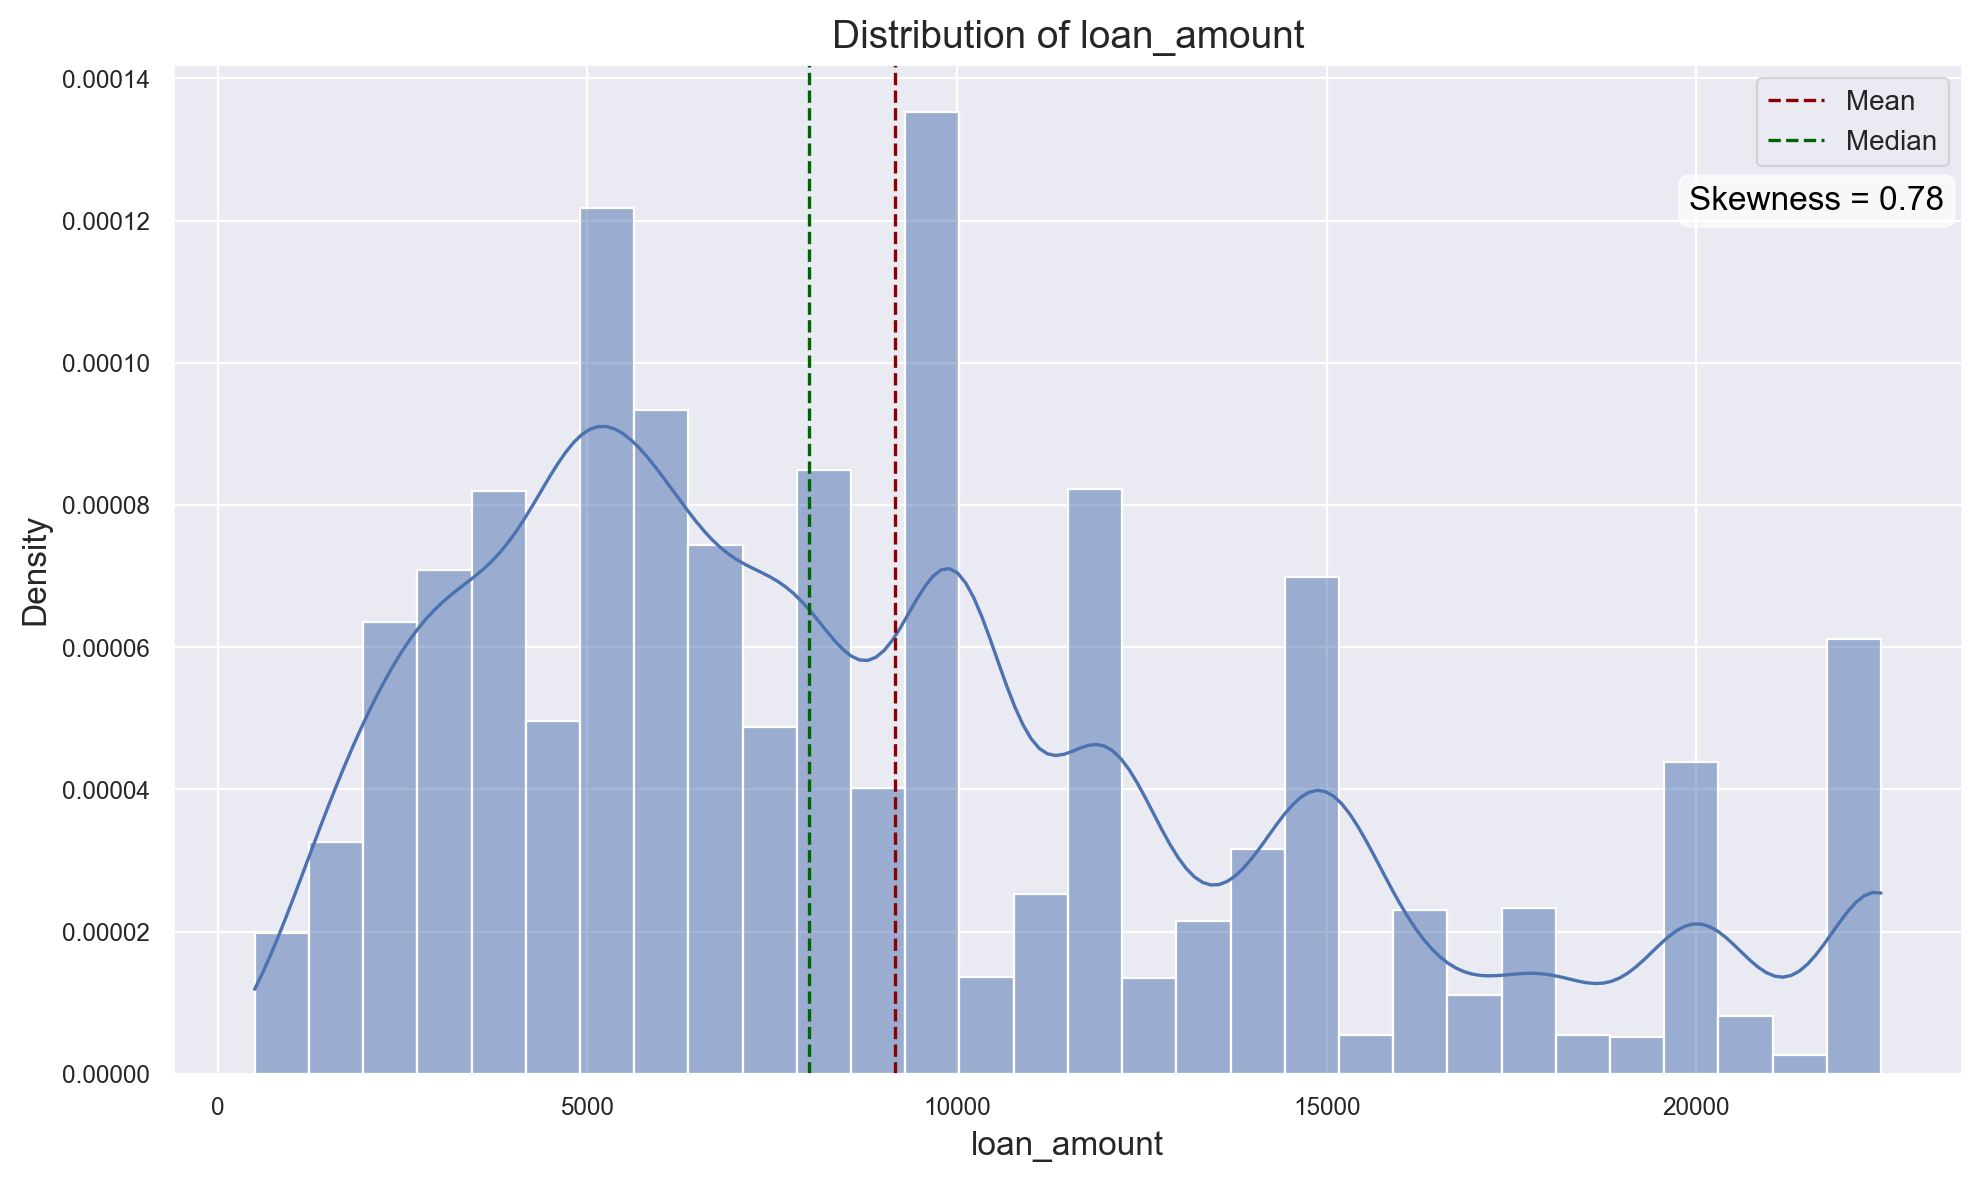

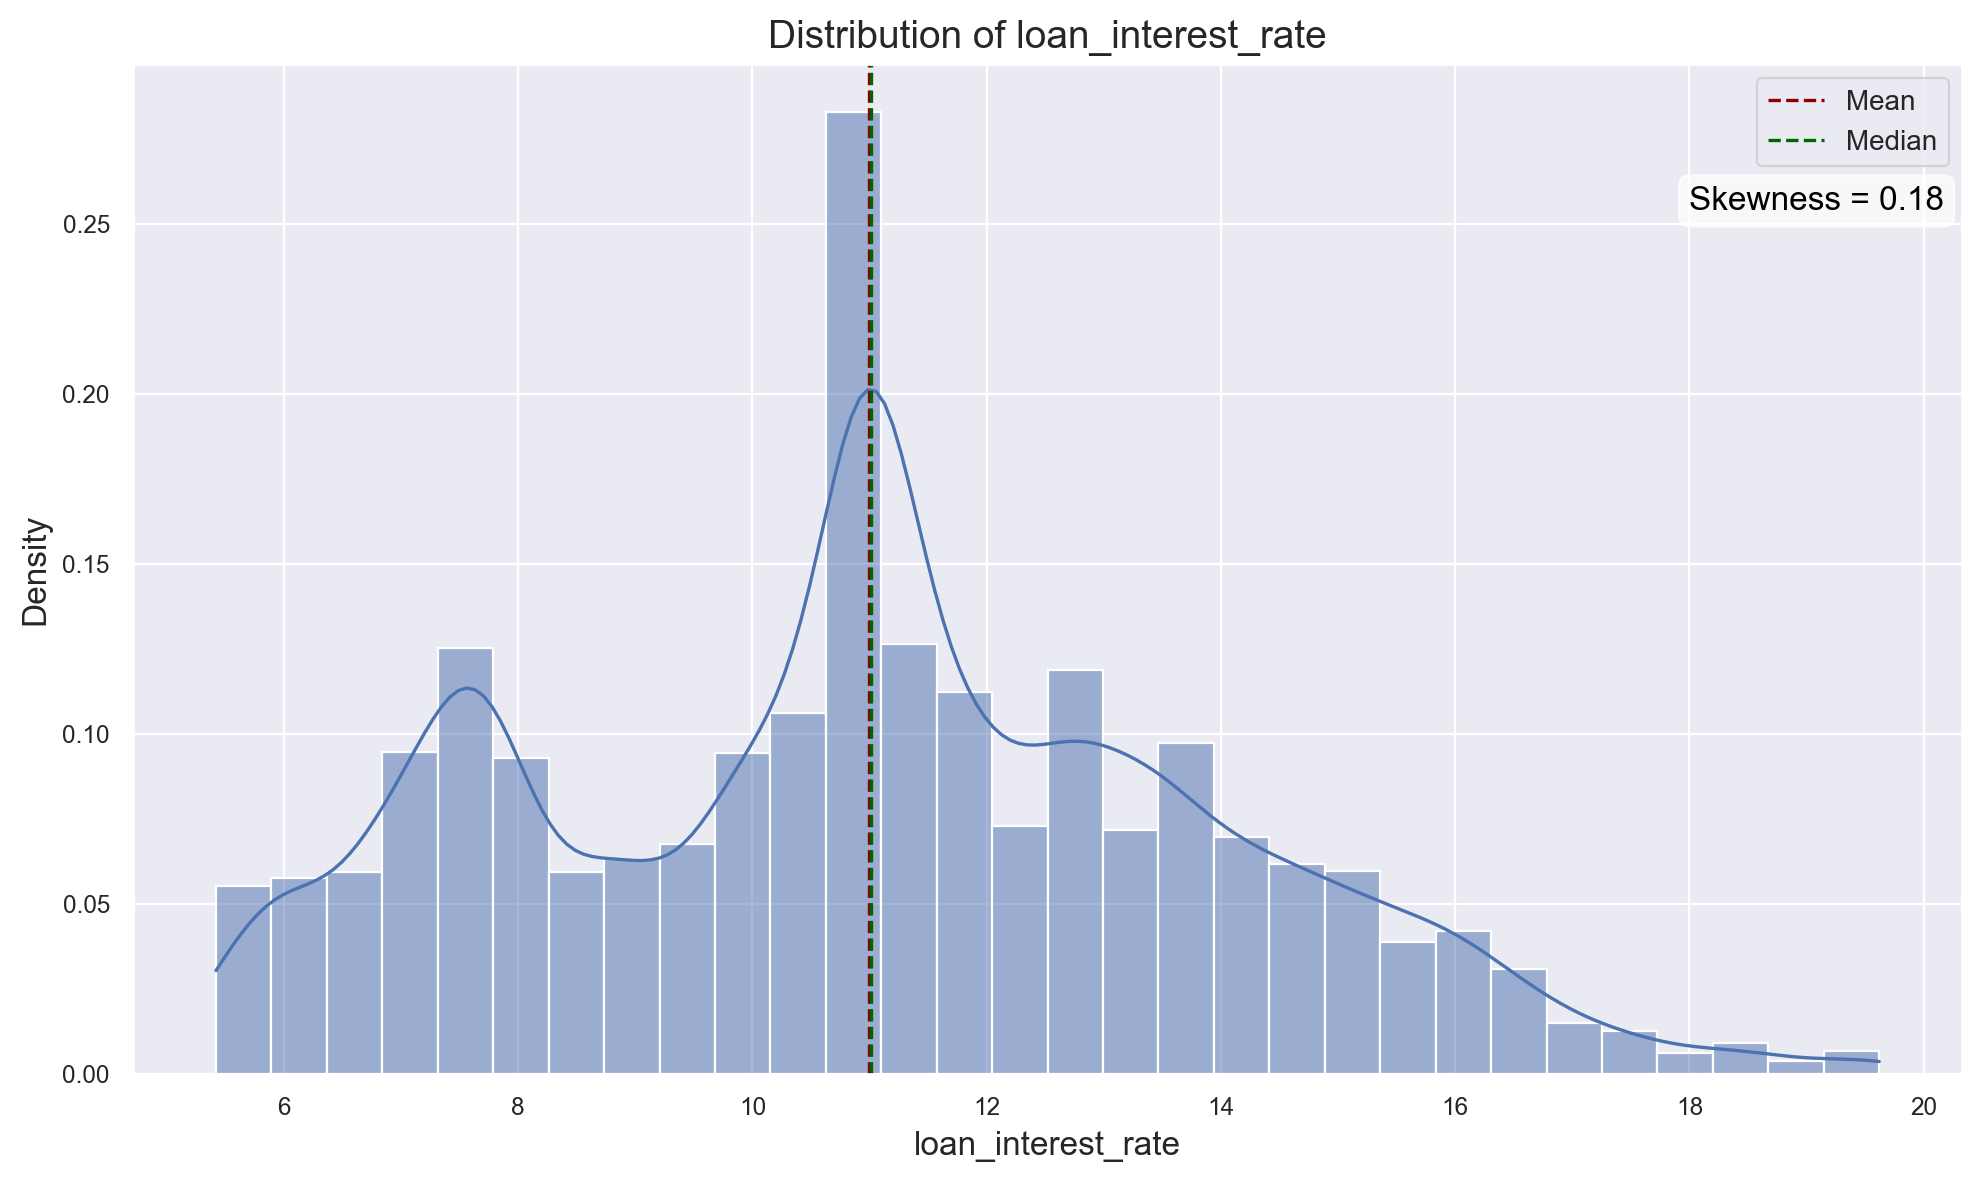

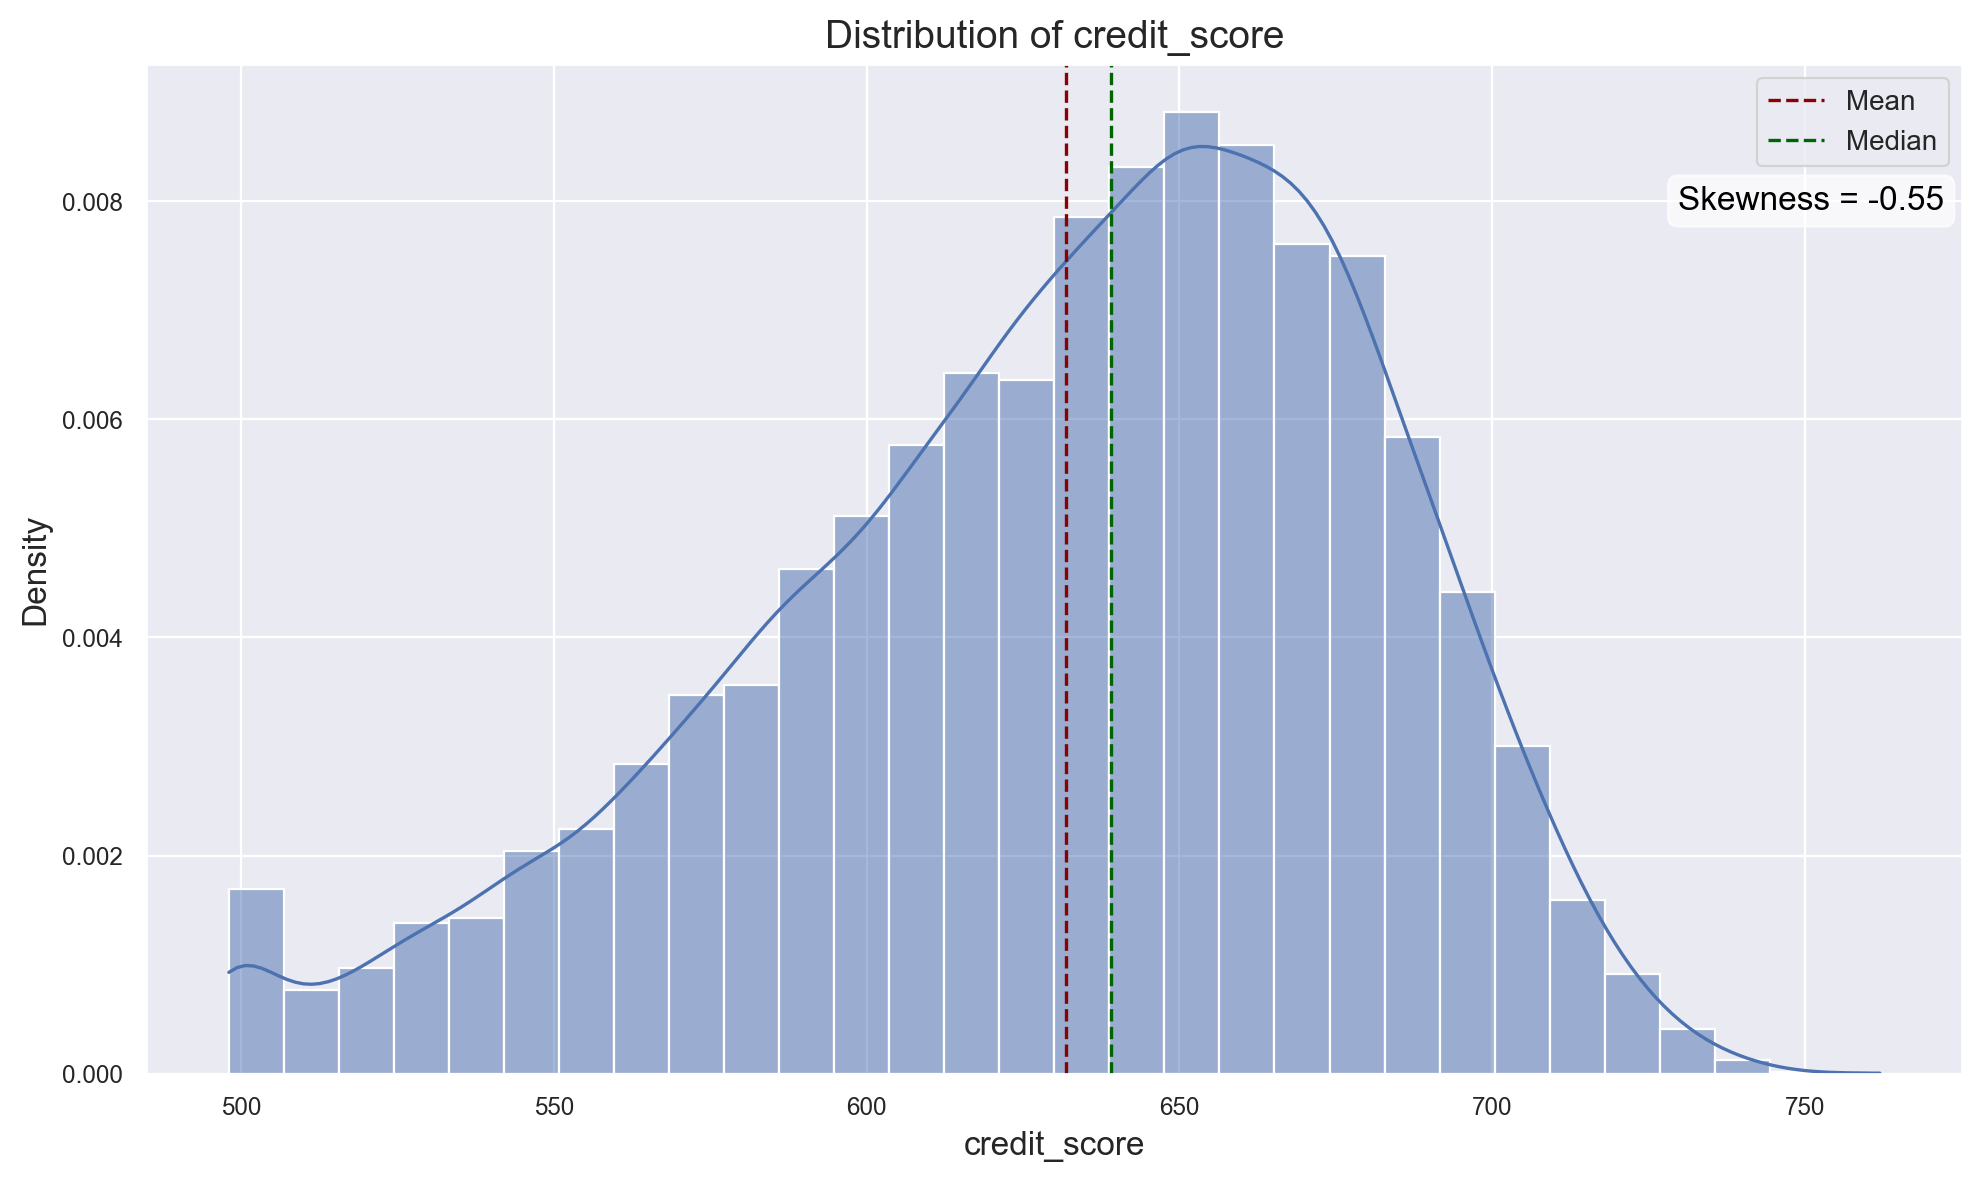

In [15]:
for col in num_variables:
    helper.create_distribution_plot(X_train, col)

They are mild in skewness so we use Yeo-Johnson transformation (refer to this [article](https://www.numberanalytics.com/blog/7-powerful-yeo-johnson-transformation-techniques) for more details). Transforming even `loan_interest_rate` which has low skew (`0.19`) to scale feature and use same transformer to inverse the transformations for explainablity which we will do later. There is no harm in doing so.

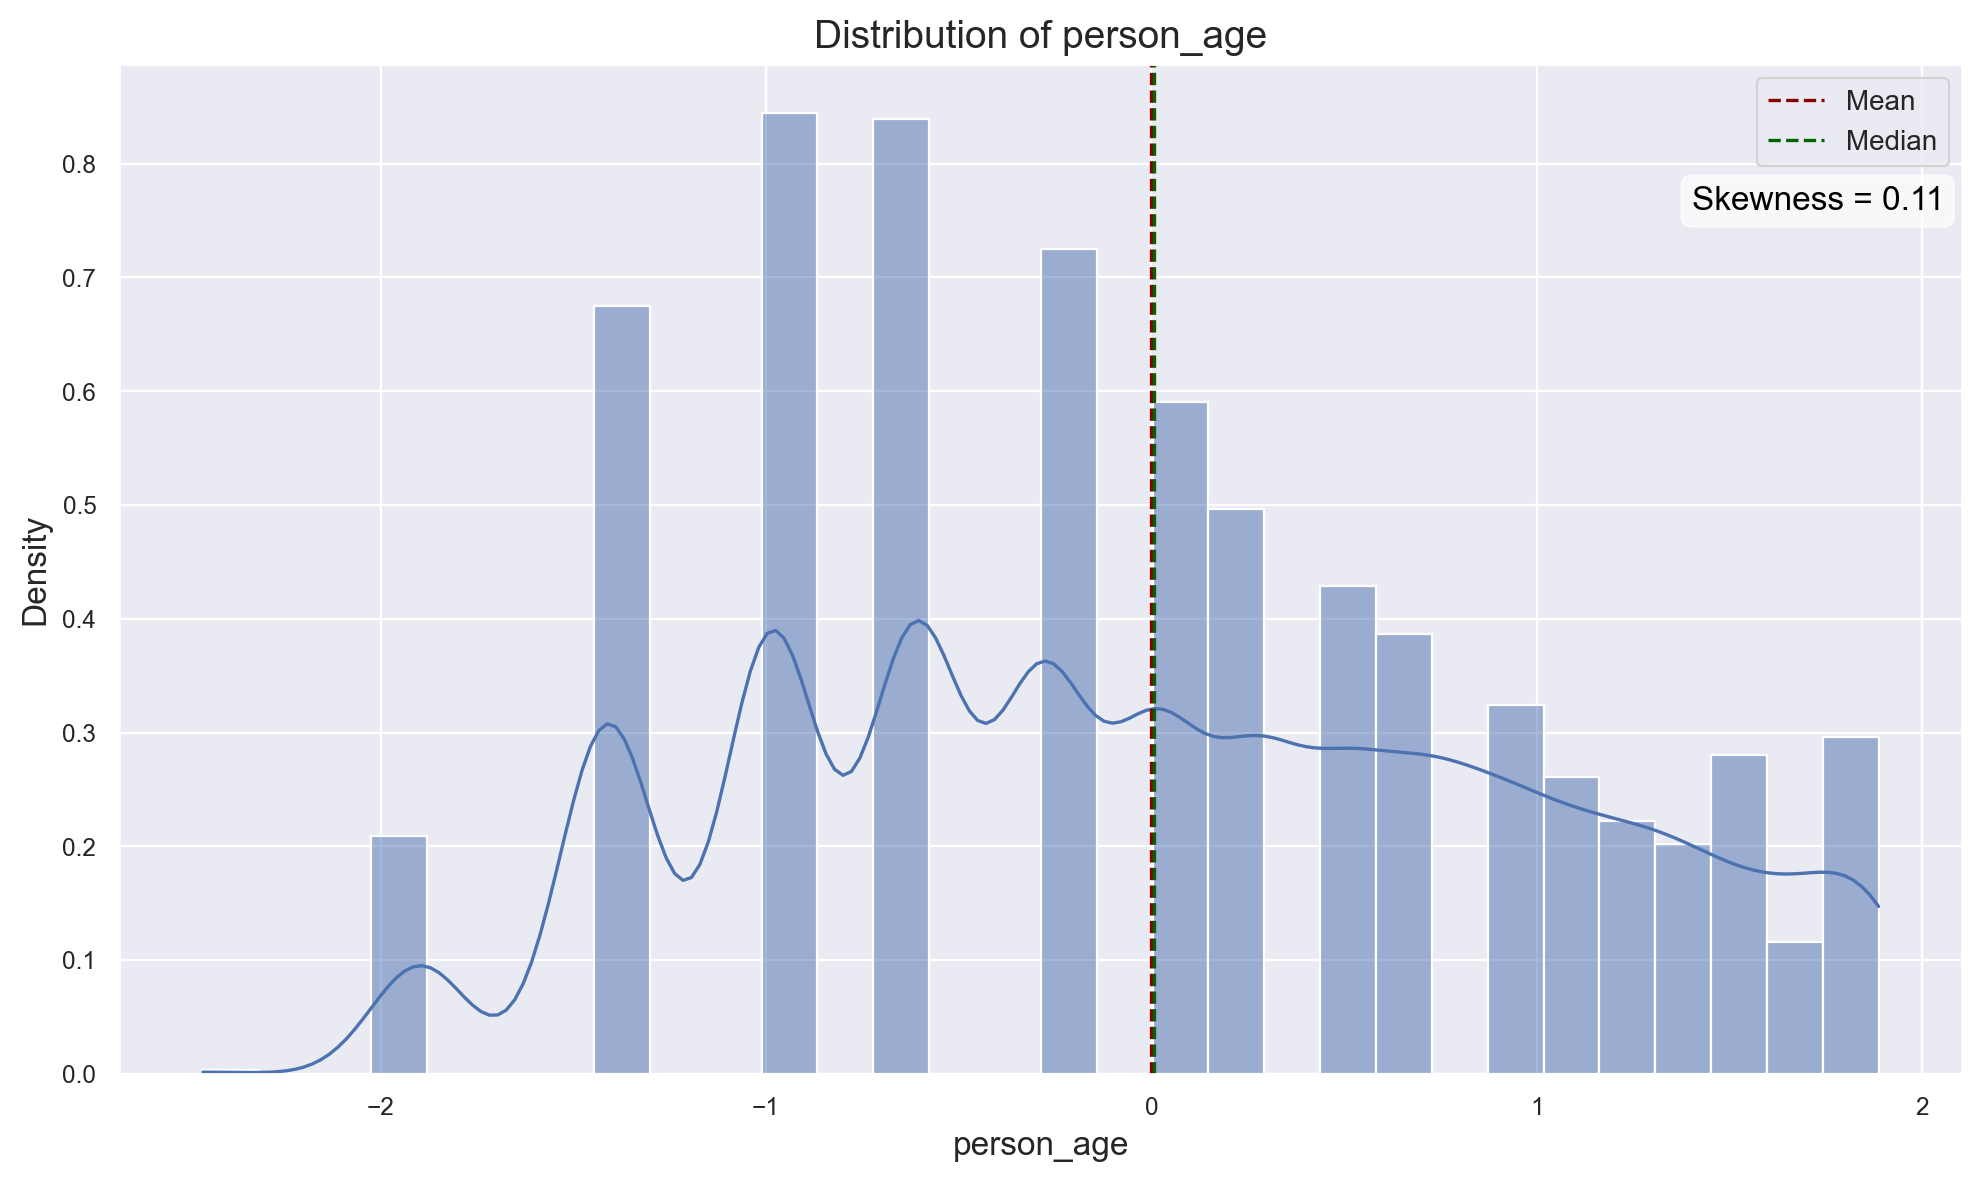

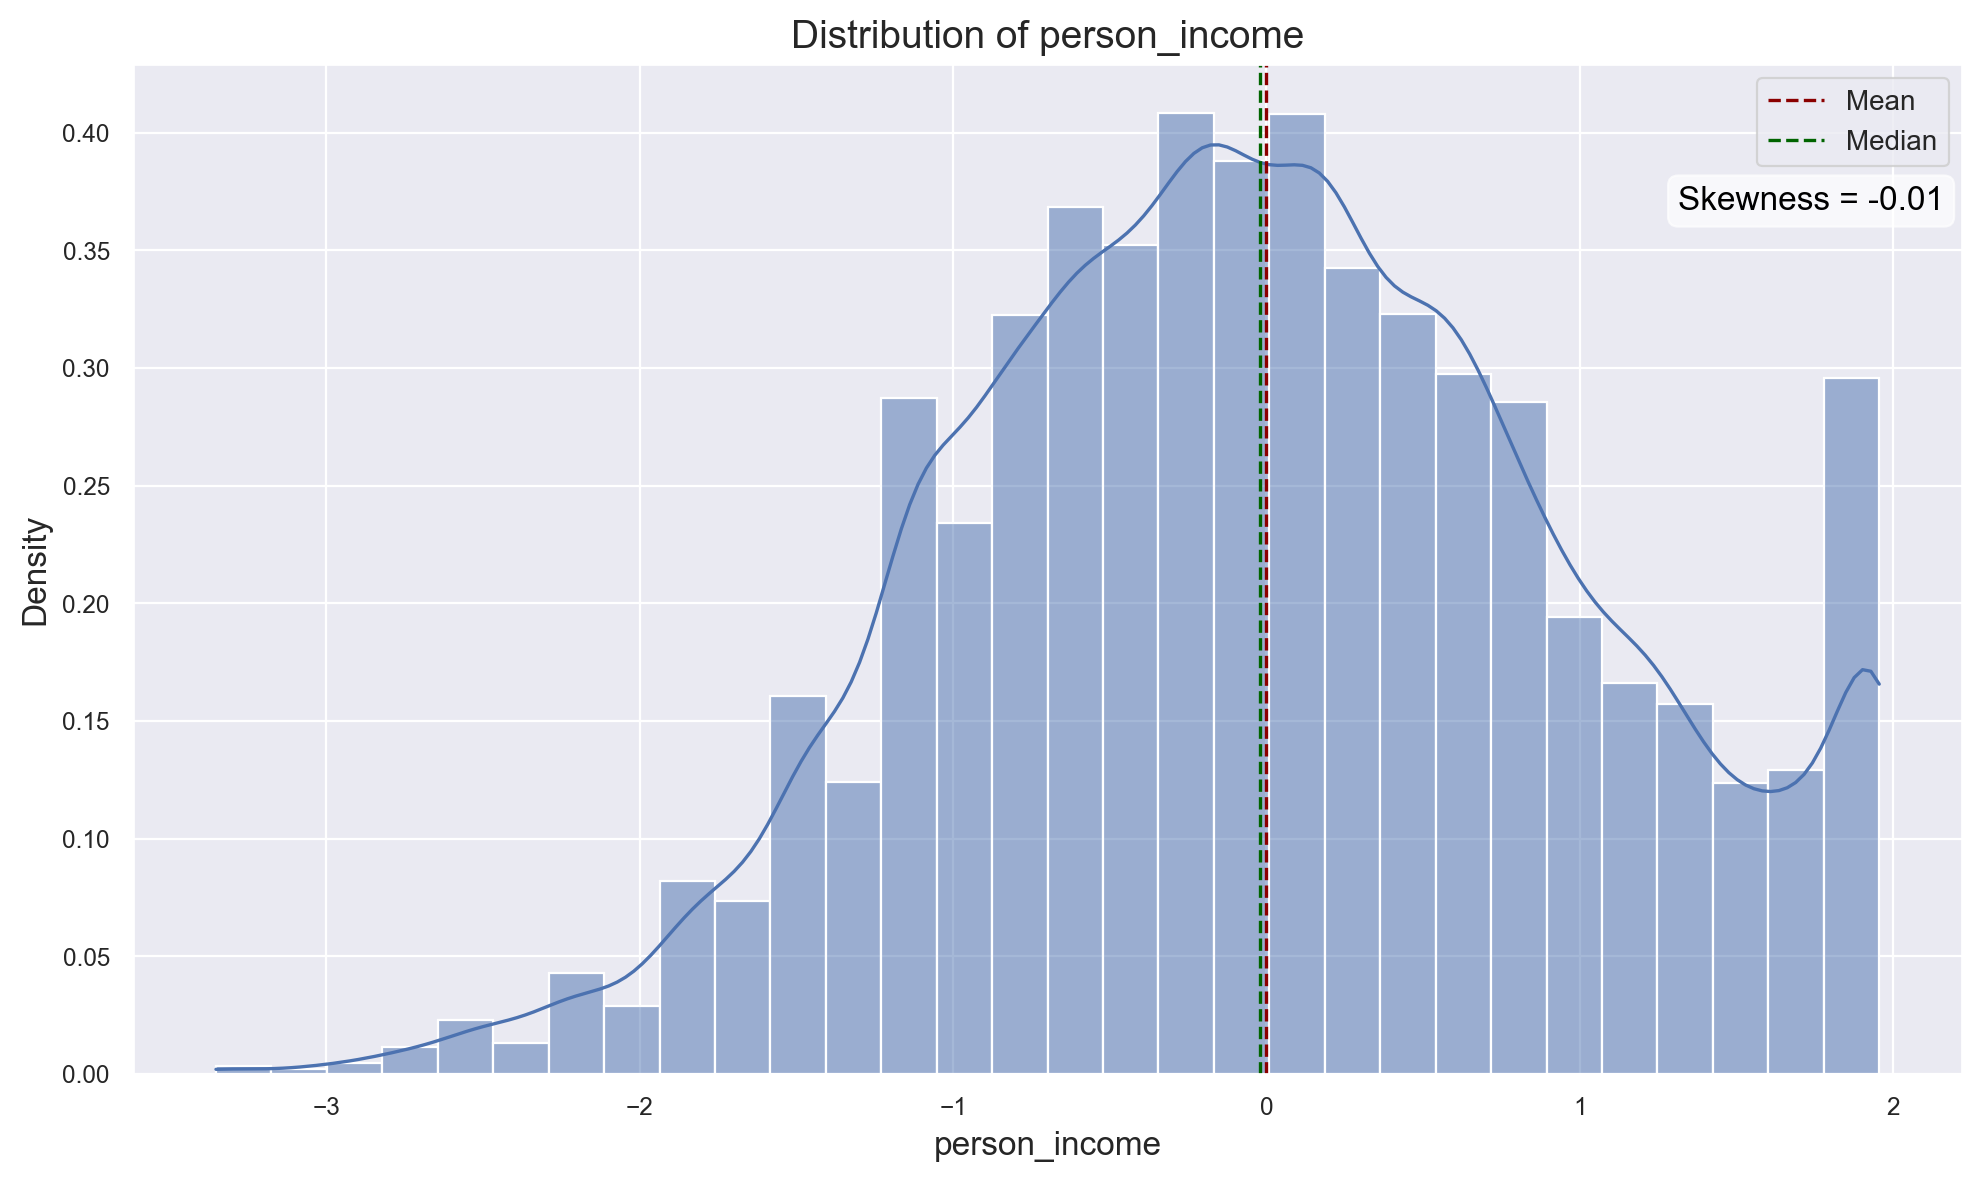

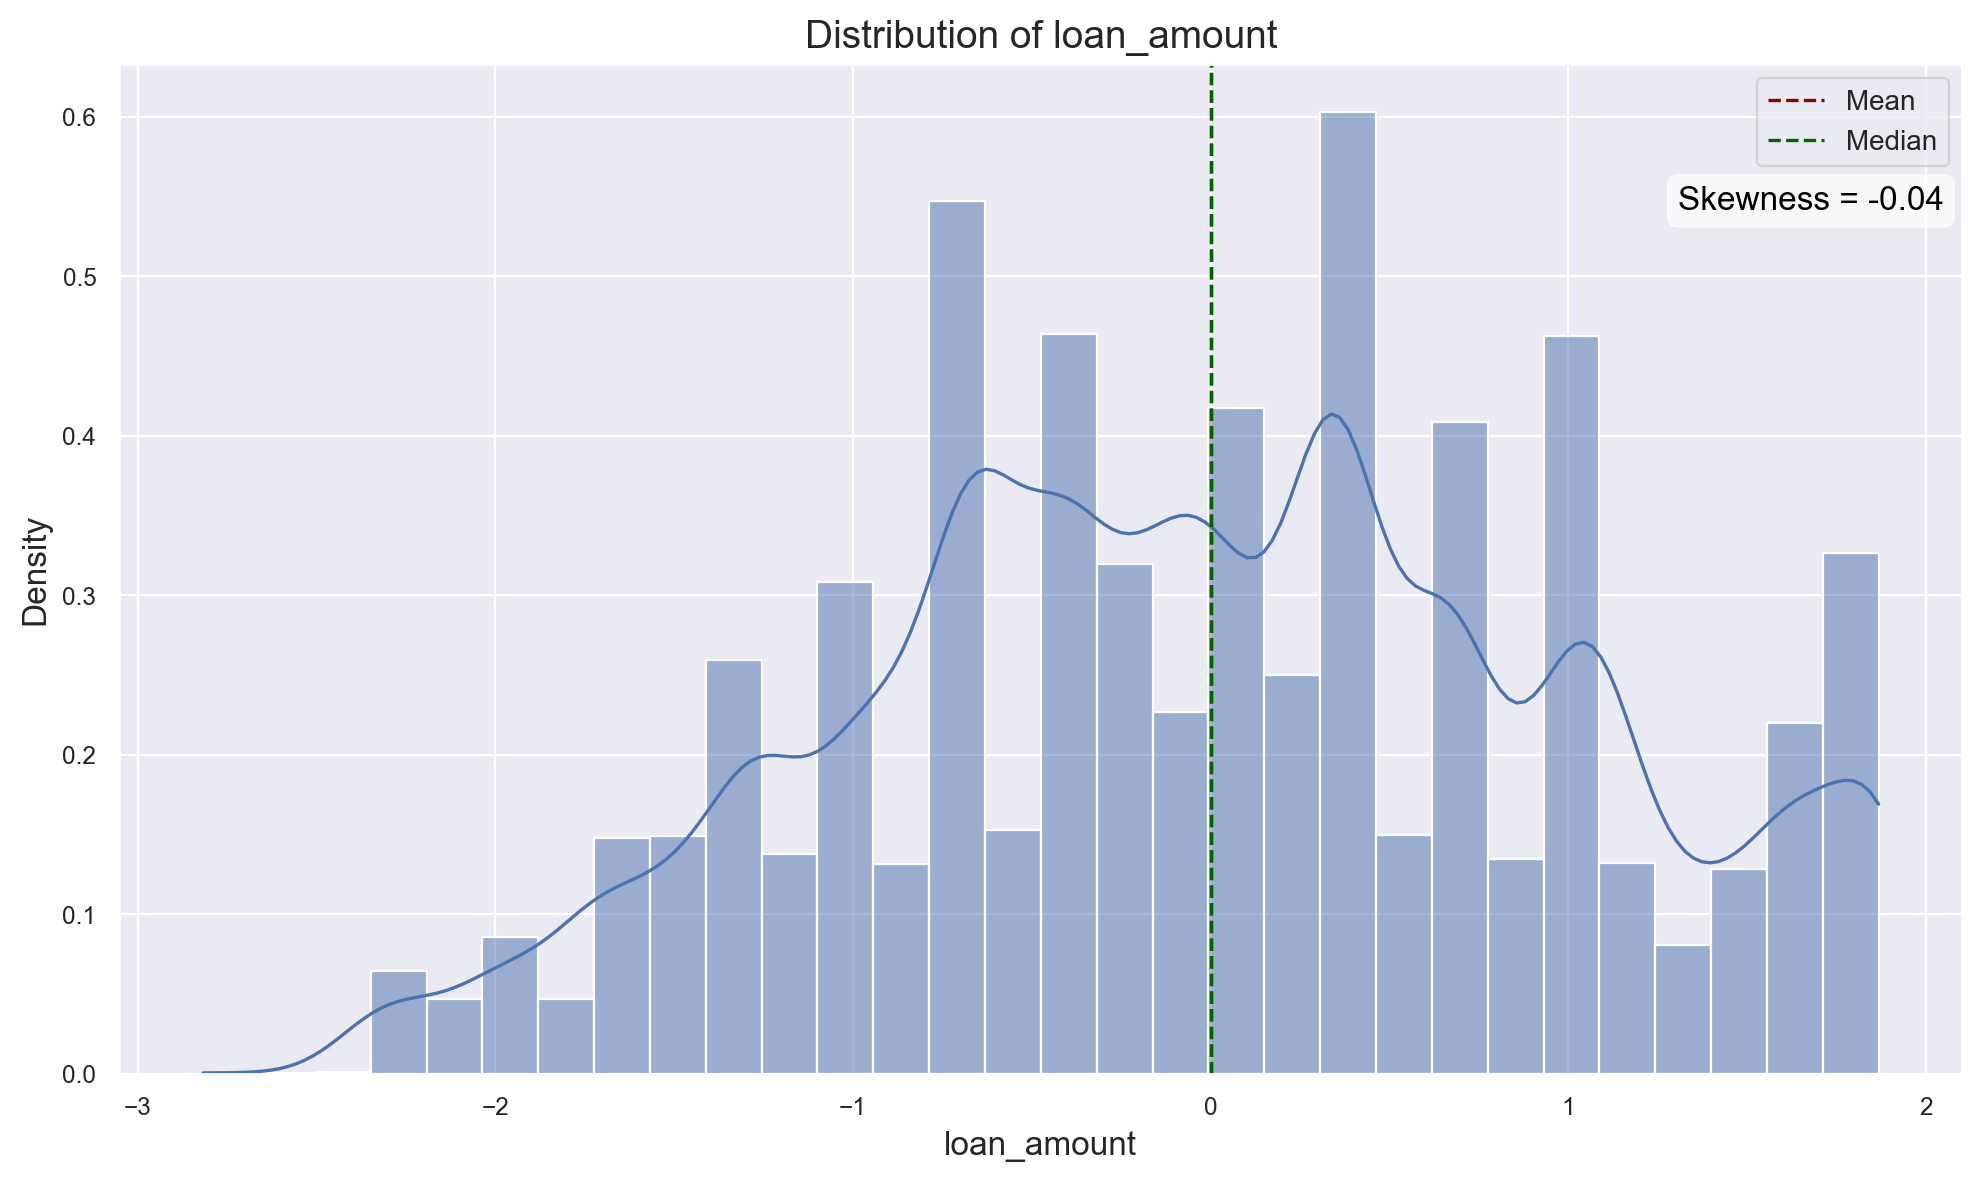

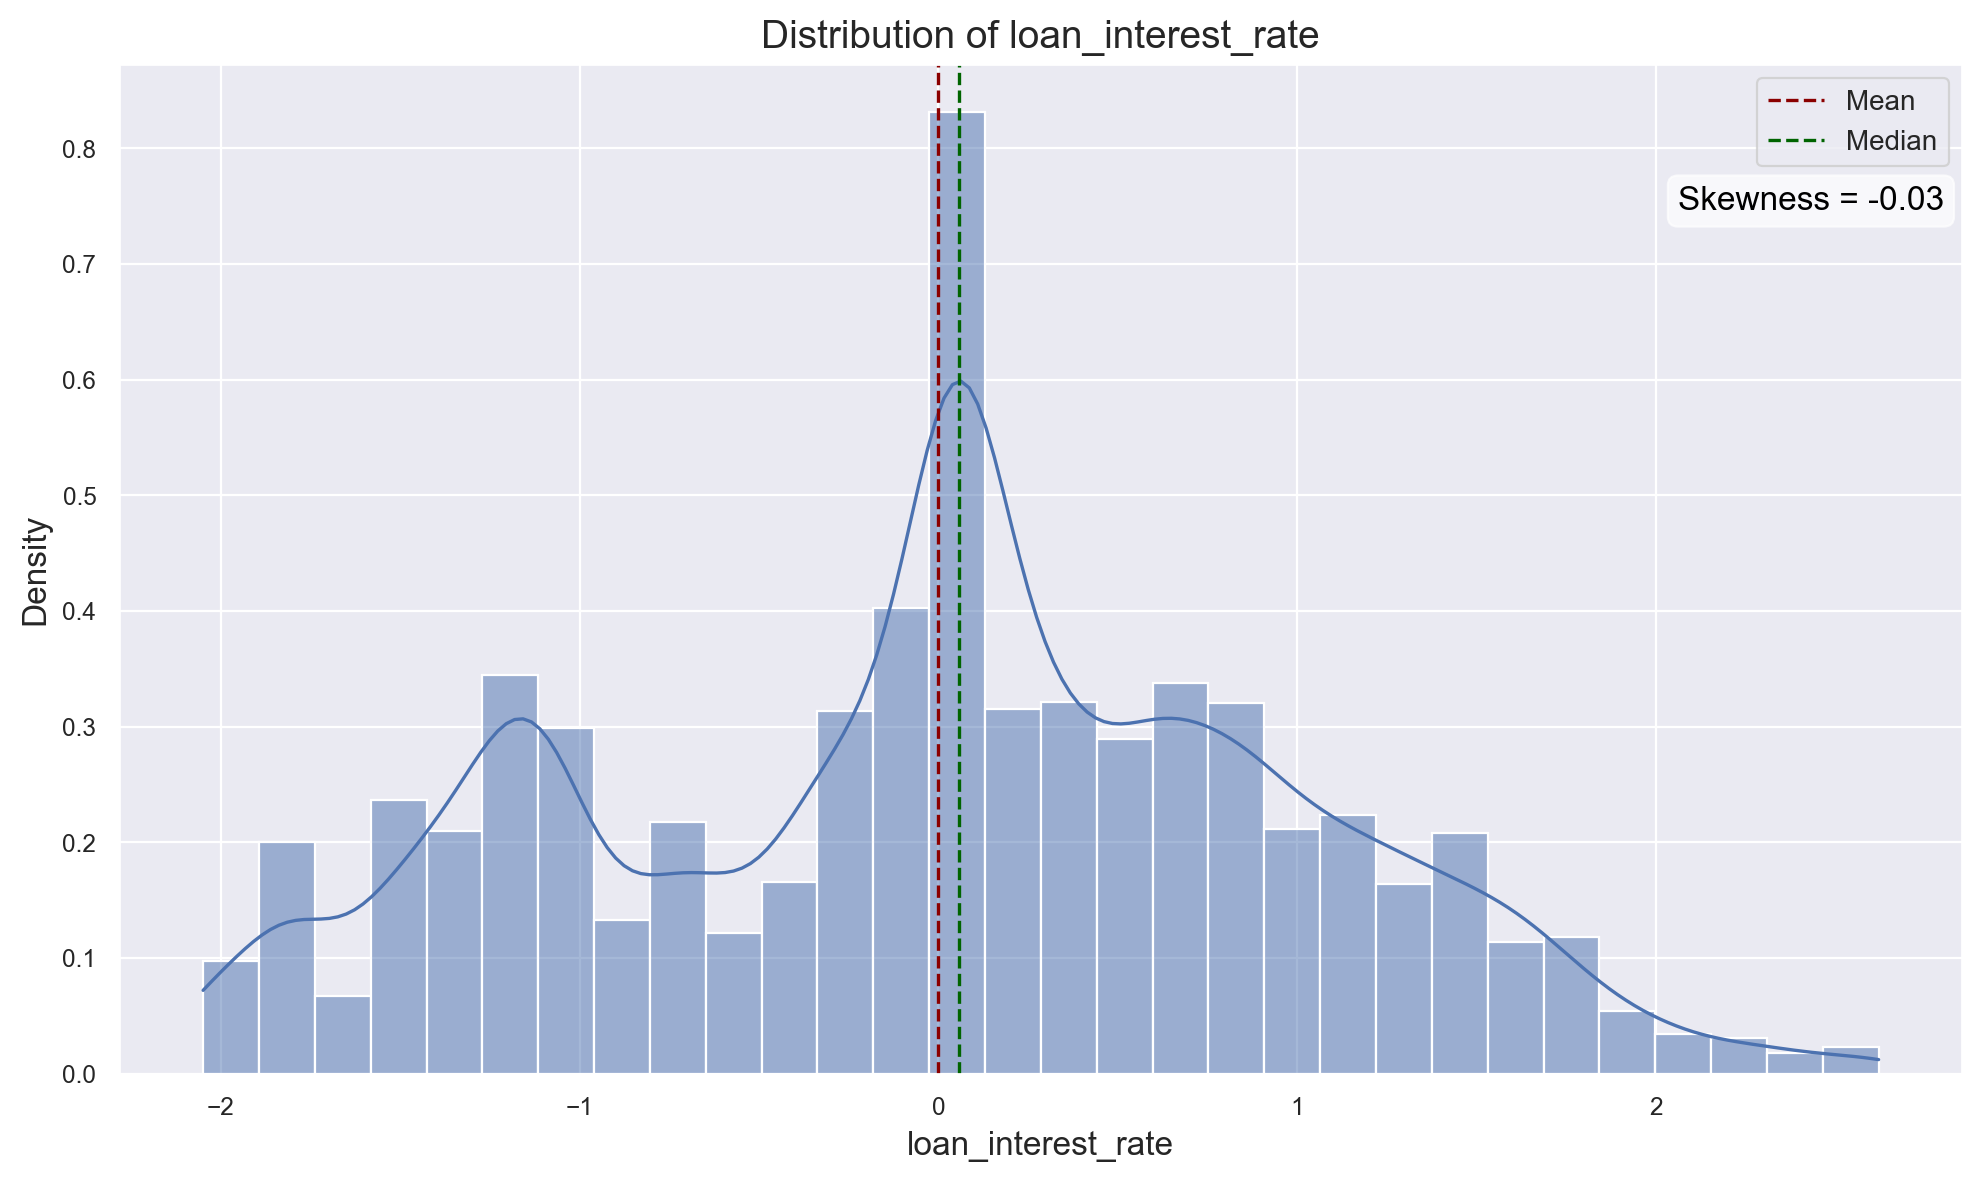

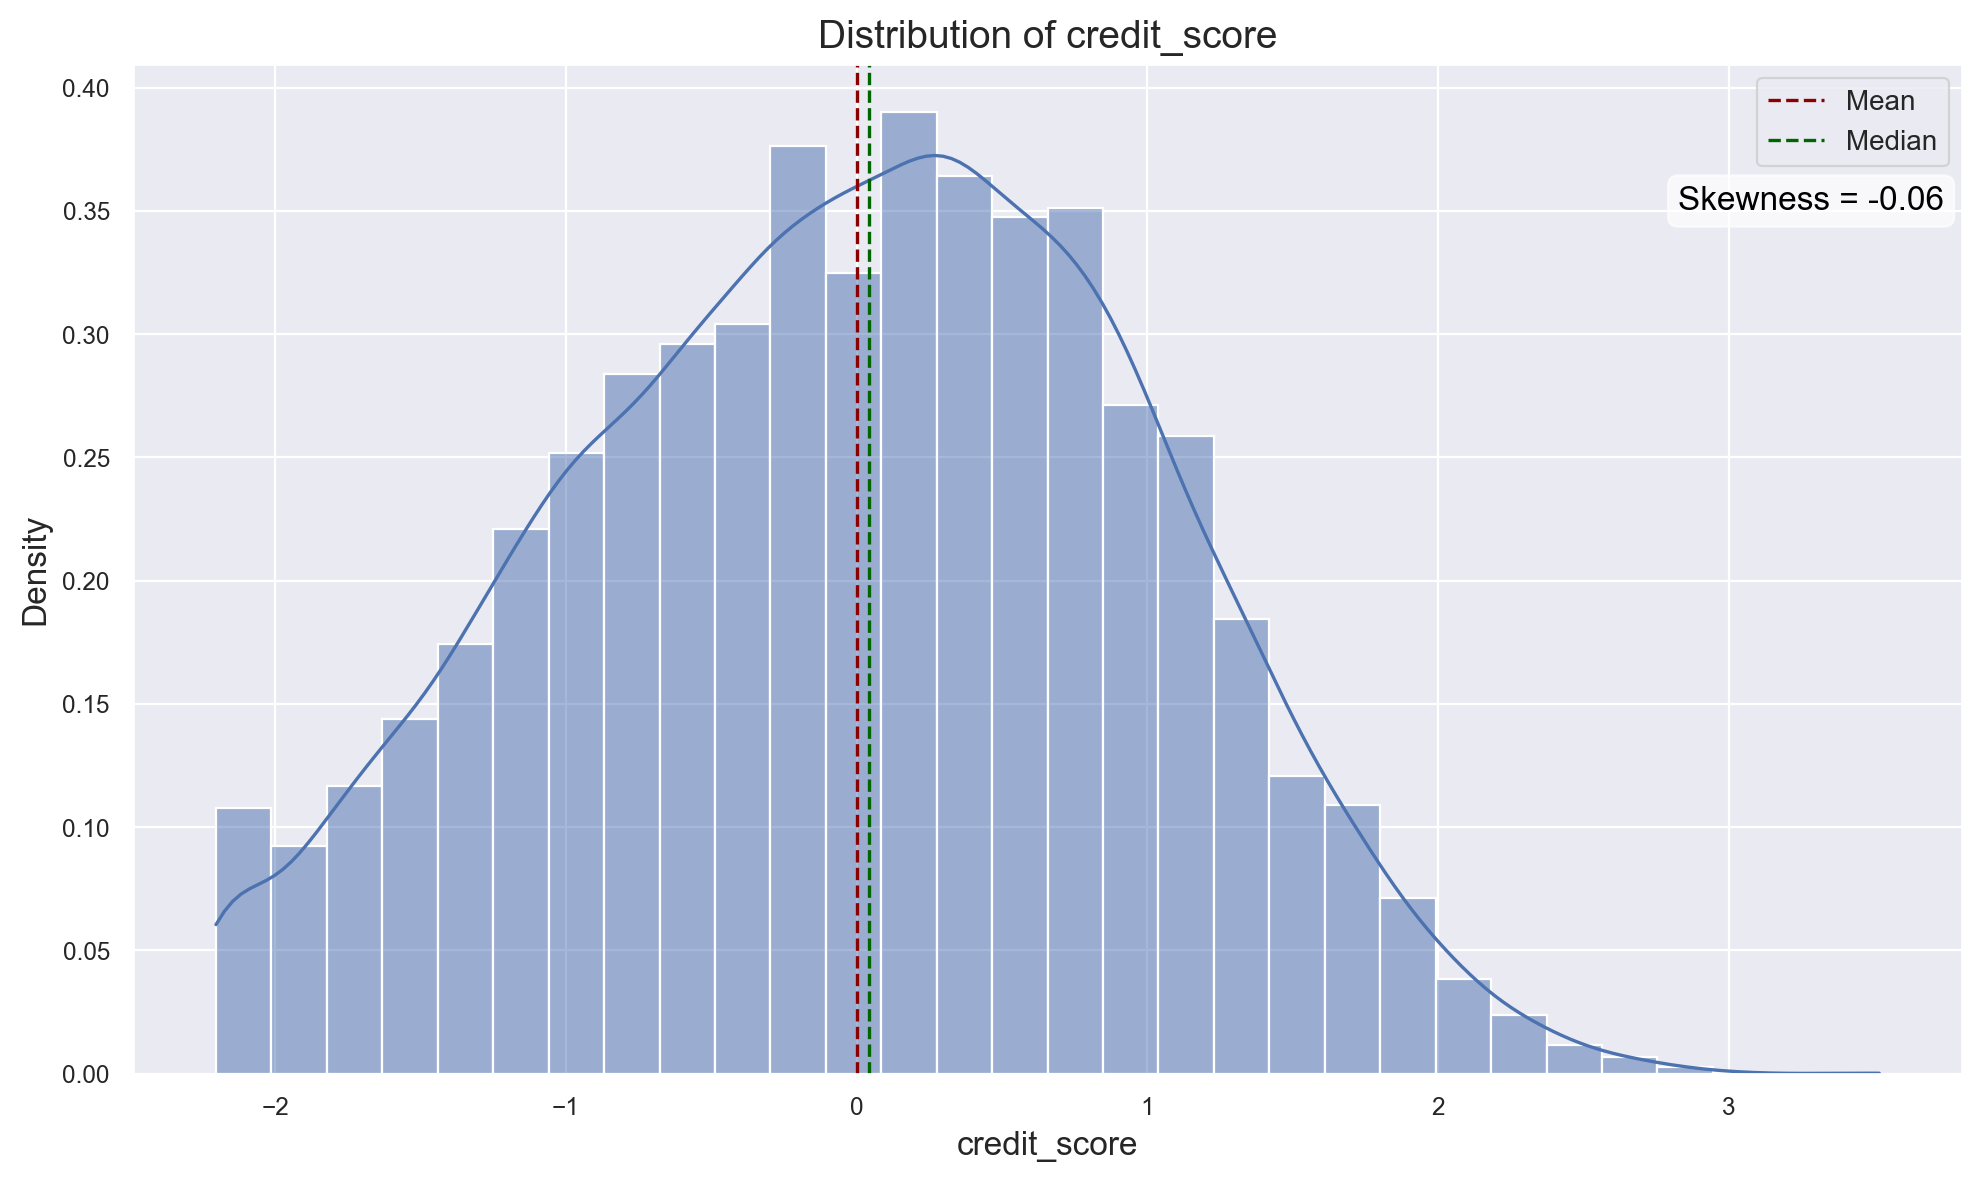

In [16]:
transformed_X_train, power_transformer = helper.power_transform(X_train, num_variables, method='yeo-johnson')

# Verify transformations
for col in num_variables:
    helper.create_distribution_plot(transformed_X_train, col)

In [17]:
transformed_X_train[num_variables].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
person_age,29771.00,-0.00,1.00,-2.46,-0.98,0.01,0.71,1.89
person_income,29771.00,-0.00,1.00,-3.35,-0.70,-0.02,0.68,1.96
loan_amount,29771.00,-0.00,1.00,-2.82,-0.67,0.00,0.66,1.87
loan_interest_rate,29771.00,-0.00,1.00,-2.05,-0.79,0.06,0.70,2.62
credit_score,29771.00,0.00,1.00,-2.20,-0.72,0.04,0.74,3.52


In [18]:
# Apply the transformation to validation and test sets
transformed_X_val = X_val.copy()
transformed_X_test = X_test.copy()

transformed_X_val.loc[:, num_variables] = power_transformer.transform(X_val[num_variables].values)
transformed_X_test.loc[:, num_variables] = power_transformer.transform(X_test[num_variables].values)

In [19]:
# Save the power transformer for future use
transformer_path = helper.root_dir / "models" / transformer_file_name

with open(transformer_path, 'wb') as f:
    pickle.dump(power_transformer, f)

In [20]:
# Save the datasets
dataset_dir = helper.root_dir / "datasets"

transformed_X_train.to_csv(dataset_dir / "train_data.csv", index=False)
transformed_X_val.to_csv(dataset_dir / "validation_set.csv", index=False)
transformed_X_test.to_csv(dataset_dir / "test_set.csv", index=False)